# Main Experiment Justice Principles: Descriptive Statistics & Visuals


This notebook analyzes Main Experiment run logs to produce descriptive statistics and publication-ready figures for the justice-principles experiment.


In [1]:
import sys
import json
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

_NOTEBOOK_DIR = Path.cwd().resolve()
for candidate in [_NOTEBOOK_DIR, *_NOTEBOOK_DIR.parents]:
    if (candidate / "experiment_execution").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

# Style and visualization
from experiment_execution.utils_experiment_execution import (
    COLORS,
    FIG_SIZES,
    FONT_SIZES,
    PRINCIPLE_COLORS,
    PRINCIPLE_DISPLAY_NAMES,
    apply_theme,
    format_principle_label,
    format_principle_labels,
)

# Constants
from experiment_execution.utils_experiment_execution import (
    CERTAINTY_TO_SCORE,
    FINAL_WAVE,
    PRINCIPLE_LABELS,
    PRINCIPLE_ORDER,
    WAVE_DEFINITIONS,
    WAVE_ORDER,
)

# Data loading
from experiment_execution.utils_experiment_execution import (
    load_experiment_runs,
    extract_run_metrics,
    extract_vote_rounds,
    extract_rankings,
    extract_income_classes,
    build_transition_data,
    create_transition_matrix,
    create_preference_ordering_table,
    prepare_switcher_analysis,
    summarize_income_preferences,
)

# Visualization functions
from experiment_execution.utils_experiment_execution import (
    plot_floor_constraint_distribution,
    plot_rounds_to_outcome,
    plot_preference_stability,
    plot_transition_heatmaps,
    plot_long_term_stability,
    plot_long_term_margin,
    plot_income_preference_bars,
    plot_income_composition,
)

apply_theme()

In [2]:
def locate_project_root(markers: Tuple[str, ...] = ("experiment_execution", "config")) -> Path:
    """Find the project root by looking for known directories."""
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError("Could not locate project root from current working directory.")


PROJECT_ROOT = locate_project_root()
DATA_DIR = PROJECT_ROOT / "experiment_execution" / "main_experiment" / "results"
TERMINAL_DIR = PROJECT_ROOT / "experiment_execution" / "main_experiment" / "terminal_outputs"


In [3]:
# Load all Main Experiment runs
runs = load_experiment_runs(
    results_dir=DATA_DIR,
    pattern="main_experiment_condition_*_config_results.json",
    terminal_outputs_dir=TERMINAL_DIR,
    log_pattern="main_experiment_condition_*_log",
)

# Extract structured data
run_metrics_records = [extract_run_metrics(run_id, run_data) for run_id, run_data in runs]
vote_round_records = []
top_choice_records = []
long_ranking_records = []

for run_id, run_data in runs:
    vote_round_records.extend(extract_vote_rounds(run_id, run_data))
    top_rows, long_rows = extract_rankings(run_id, run_data)
    top_choice_records.extend(top_rows)
    long_ranking_records.extend(long_rows)

run_metrics = pd.DataFrame(run_metrics_records)
vote_rounds = pd.DataFrame(vote_round_records)
ranking_long = pd.DataFrame(long_ranking_records)
ranking_top = pd.DataFrame(top_choice_records)

ranking_top["wave_label"] = pd.Categorical(ranking_top["wave_label"], categories=WAVE_ORDER, ordered=True)
ranking_long["wave_label"] = pd.Categorical(ranking_long["wave_label"], categories=WAVE_ORDER, ordered=True)

print(f"Loaded {len(runs)} result files.")
run_metrics.head()


Loaded 33 result files.


,run_id,consensus_reached,consensus_principle,rounds_to_outcome,max_rounds,total_vote_attempts,successful_votes,total_vote_rounds
0,main_experiment_condition_10_config_results,True,Max Avg + Floor,8,10,1,1,1
1,main_experiment_condition_11_config_results,True,Max Avg + Floor,4,10,1,1,1
2,main_experiment_condition_12_config_results,True,Max Avg + Floor,7,10,1,1,1
3,main_experiment_condition_13_config_results,True,Max Avg + Floor,6,10,1,1,1
4,main_experiment_condition_14_config_results,True,Max Avg + Floor,4,10,1,1,1


## Data Summary

In [4]:

num_runs = run_metrics.shape[0]
unique_agents = ranking_top[["run_id", "agent"]].drop_duplicates().shape[0]
num_waves = ranking_top["wave_label"].nunique()
consensus_runs = run_metrics[run_metrics["consensus_reached"] == True].shape[0]

summary_df = pd.DataFrame(
    {
        "Metric": ["Runs", "Consensus runs", "Agent sessions", "Preference waves"],
        "Value": [num_runs, consensus_runs, unique_agents, num_waves]
    }
)

display(summary_df)

expected_agents = unique_agents
coverage = (ranking_top.drop_duplicates(subset=["run_id", "agent", "wave_label"])
                     .groupby("wave_label")
                     .size()
                     .reindex(WAVE_ORDER, fill_value=0))
missing = expected_agents - coverage
coverage_table = pd.DataFrame({"Responses": coverage, "Missing": missing})
display(coverage_table)


,Metric,Value
0,Runs,33
1,Consensus runs,30
2,Agent sessions,165
3,Preference waves,4


/var/folders/wf/_h59fnv53s7476fhw5sn5smh0000gn/T/ipykernel_63919/1307473778.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("wave_label")


,Responses,Missing
wave_label,,
Wave 1 - Initial,165,0
Wave 2 - Post-Explanation,165,0
Wave 3 - Final Phase 1,165,0
Wave 4 - Post-Group,165,0


## Preference Orderings by Wave

Below are frequency tables showing how many agents reported each complete ranking of the four justice principles at each measurement wave. Orderings are shown from most to least popular.

In [5]:
# Use centralized function to generate preference ordering tables

# Generate tables for all four waves
print("=" * 100)
print("WAVE 1 - INITIAL (After Principle Introduction)")
print("=" * 100)
wave1_table = create_preference_ordering_table(ranking_long, "Wave 1 - Initial")
display(wave1_table)

print("\n" + "=" * 100)
print("WAVE 2 - POST-EXPLANATION (After Detailed Explanation)")
print("=" * 100)
wave2_table = create_preference_ordering_table(ranking_long, "Wave 2 - Post-Explanation")
display(wave2_table)

print("\n" + "=" * 100)
print("WAVE 3 - FINAL PHASE 1 (End of Individual Deliberation)")
print("=" * 100)
wave3_table = create_preference_ordering_table(ranking_long, "Wave 3 - Final Phase 1")
display(wave3_table)

print("\n" + "=" * 100)
print("WAVE 4 - POST-GROUP (After Group Discussion)")
print("=" * 100)
wave4_table = create_preference_ordering_table(ranking_long, "Wave 4 - Post-Group")
display(wave4_table)

# Summary statistics across waves
print("\n" + "=" * 100)
print("SUMMARY: Unique Orderings Per Wave")
print("=" * 100)
summary_data = []
for wave in WAVE_ORDER:
    wave_data = ranking_long[ranking_long["wave_label"] == wave]
    if not wave_data.empty:
        orderings = []
        for (run_id, agent), group in wave_data.groupby(["run_id", "agent"]):
            sorted_group = group.sort_values("rank")
            ordering = tuple(sorted_group["principle_label"].tolist())
            orderings.append(ordering)
        unique_count = len(set(orderings))
        total_count = len(orderings)
        summary_data.append({
            "Wave": wave,
            "Total Responses": total_count,
            "Unique Orderings": unique_count,
            "Diversity Ratio": f"{unique_count}/{total_count} ({unique_count/total_count*100:.1f}%)"
        })

summary_df = pd.DataFrame(summary_data)
display(summary_df)

WAVE 1 - INITIAL (After Principle Introduction)


,Preference Ordering,Count,Percentage
0,Max Avg + Floor > Max Floor > Max Avg + Range ...,100,60.6
1,Max Avg + Floor > Max Avg + Range > Max Floor ...,27,16.4
2,Max Avg + Floor > Max Floor > Max Avg Income >...,21,12.7
3,Max Avg Income > Max Avg + Floor > Max Floor >...,13,7.9
4,Max Avg + Floor > Max Avg Income > Max Floor >...,2,1.2
5,Max Avg Income > Max Avg + Floor > Max Avg + R...,2,1.2



WAVE 2 - POST-EXPLANATION (After Detailed Explanation)


,Preference Ordering,Count,Percentage
0,Max Avg + Floor > Max Floor > Max Avg + Range ...,88,53.3
1,Max Avg + Floor > Max Avg + Range > Max Floor ...,48,29.1
2,Max Avg + Floor > Max Floor > Max Avg Income >...,18,10.9
3,Max Avg + Floor > Max Avg + Range > Max Avg In...,6,3.6
4,Max Avg + Floor > Max Avg Income > Max Floor >...,3,1.8
5,Max Avg + Range > Max Avg + Floor > Max Floor ...,1,0.6
6,Max Avg Income > Max Avg + Floor > Max Floor >...,1,0.6



WAVE 3 - FINAL PHASE 1 (End of Individual Deliberation)


,Preference Ordering,Count,Percentage
0,Max Avg + Floor > Max Floor > Max Avg + Range ...,68,41.2
1,Max Avg + Floor > Max Avg + Range > Max Floor ...,47,28.5
2,Max Avg + Floor > Max Floor > Max Avg Income >...,15,9.1
3,Max Avg + Floor > Max Avg Income > Max Floor >...,9,5.5
4,Max Avg + Floor > Max Avg + Range > Max Avg In...,7,4.2
5,Max Avg Income > Max Avg + Floor > Max Avg + R...,7,4.2
6,Max Avg + Floor > Max Avg Income > Max Avg + R...,5,3.0
7,Max Avg Income > Max Avg + Floor > Max Floor >...,4,2.4
8,Max Floor > Max Avg + Floor > Max Avg + Range ...,3,1.8



WAVE 4 - POST-GROUP (After Group Discussion)


,Preference Ordering,Count,Percentage
0,Max Avg + Floor > Max Floor > Max Avg + Range ...,59,35.8
1,Max Avg + Floor > Max Avg + Range > Max Floor ...,43,26.1
2,Max Avg + Floor > Max Avg Income > Max Avg + R...,16,9.7
3,Max Avg + Floor > Max Floor > Max Avg Income >...,10,6.1
4,Max Avg + Floor > Max Avg Income > Max Floor >...,7,4.2
5,Max Floor > Max Avg Income > Max Avg + Floor >...,7,4.2
6,Max Avg Income > Max Avg + Floor > Max Avg + R...,6,3.6
7,Max Floor > Max Avg + Floor > Max Avg + Range ...,6,3.6
8,Max Floor > Max Avg + Floor > Max Avg Income >...,4,2.4
9,Max Avg + Floor > Max Avg + Range > Max Avg In...,2,1.2



SUMMARY: Unique Orderings Per Wave


,Wave,Total Responses,Unique Orderings,Diversity Ratio
0,Wave 1 - Initial,165,6,6/165 (3.6%)
1,Wave 2 - Post-Explanation,165,7,7/165 (4.2%)
2,Wave 3 - Final Phase 1,165,9,9/165 (5.5%)
3,Wave 4 - Post-Group,165,14,14/165 (8.5%)


## Rounds to Outcome

## Floor Constraint Amounts

In [6]:
# Use centralized visualization function
plot_floor_constraint_distribution(
    vote_rounds,
    title_suffix="Main Experiment"
)

RuntimeError: latex was not able to process the following string:
b'$0k'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./file.tex
LaTeX2e <2024-11-01> patch level 2
L3 programming layer <2025-01-18>
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/article.cls
Document Class: article 2024/06/29 v1.4n Standard LaTeX document class
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2025/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/geometry/geometry.sty
(/usr/local/texlive/2025/texmf-dist/tex/latex/graphics/keyval.sty)

Error in callback <function _draw_all_if_interactive at 0x10c5eb4c0> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: latex was not able to process the following string:
b'$0k'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./file.tex
LaTeX2e <2024-11-01> patch level 2
L3 programming layer <2025-01-18>
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/article.cls
Document Class: article 2024/06/29 v1.4n Standard LaTeX document class
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2025/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/geometry/geometry.sty
(/usr/local/texlive/2025/texmf-dist/tex/latex/graphics/keyval.sty)

RuntimeError: latex was not able to process the following string:
b'$0k'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./file.tex
LaTeX2e <2024-11-01> patch level 2
L3 programming layer <2025-01-18>
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/article.cls
Document Class: article 2024/06/29 v1.4n Standard LaTeX document class
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2025/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/geometry/geometry.sty
(/usr/local/texlive/2025/texmf-dist/tex/latex/graphics/keyval.sty)

<Figure size 3300x1500 with 1 Axes>

## Voting Attempts and Success Rate

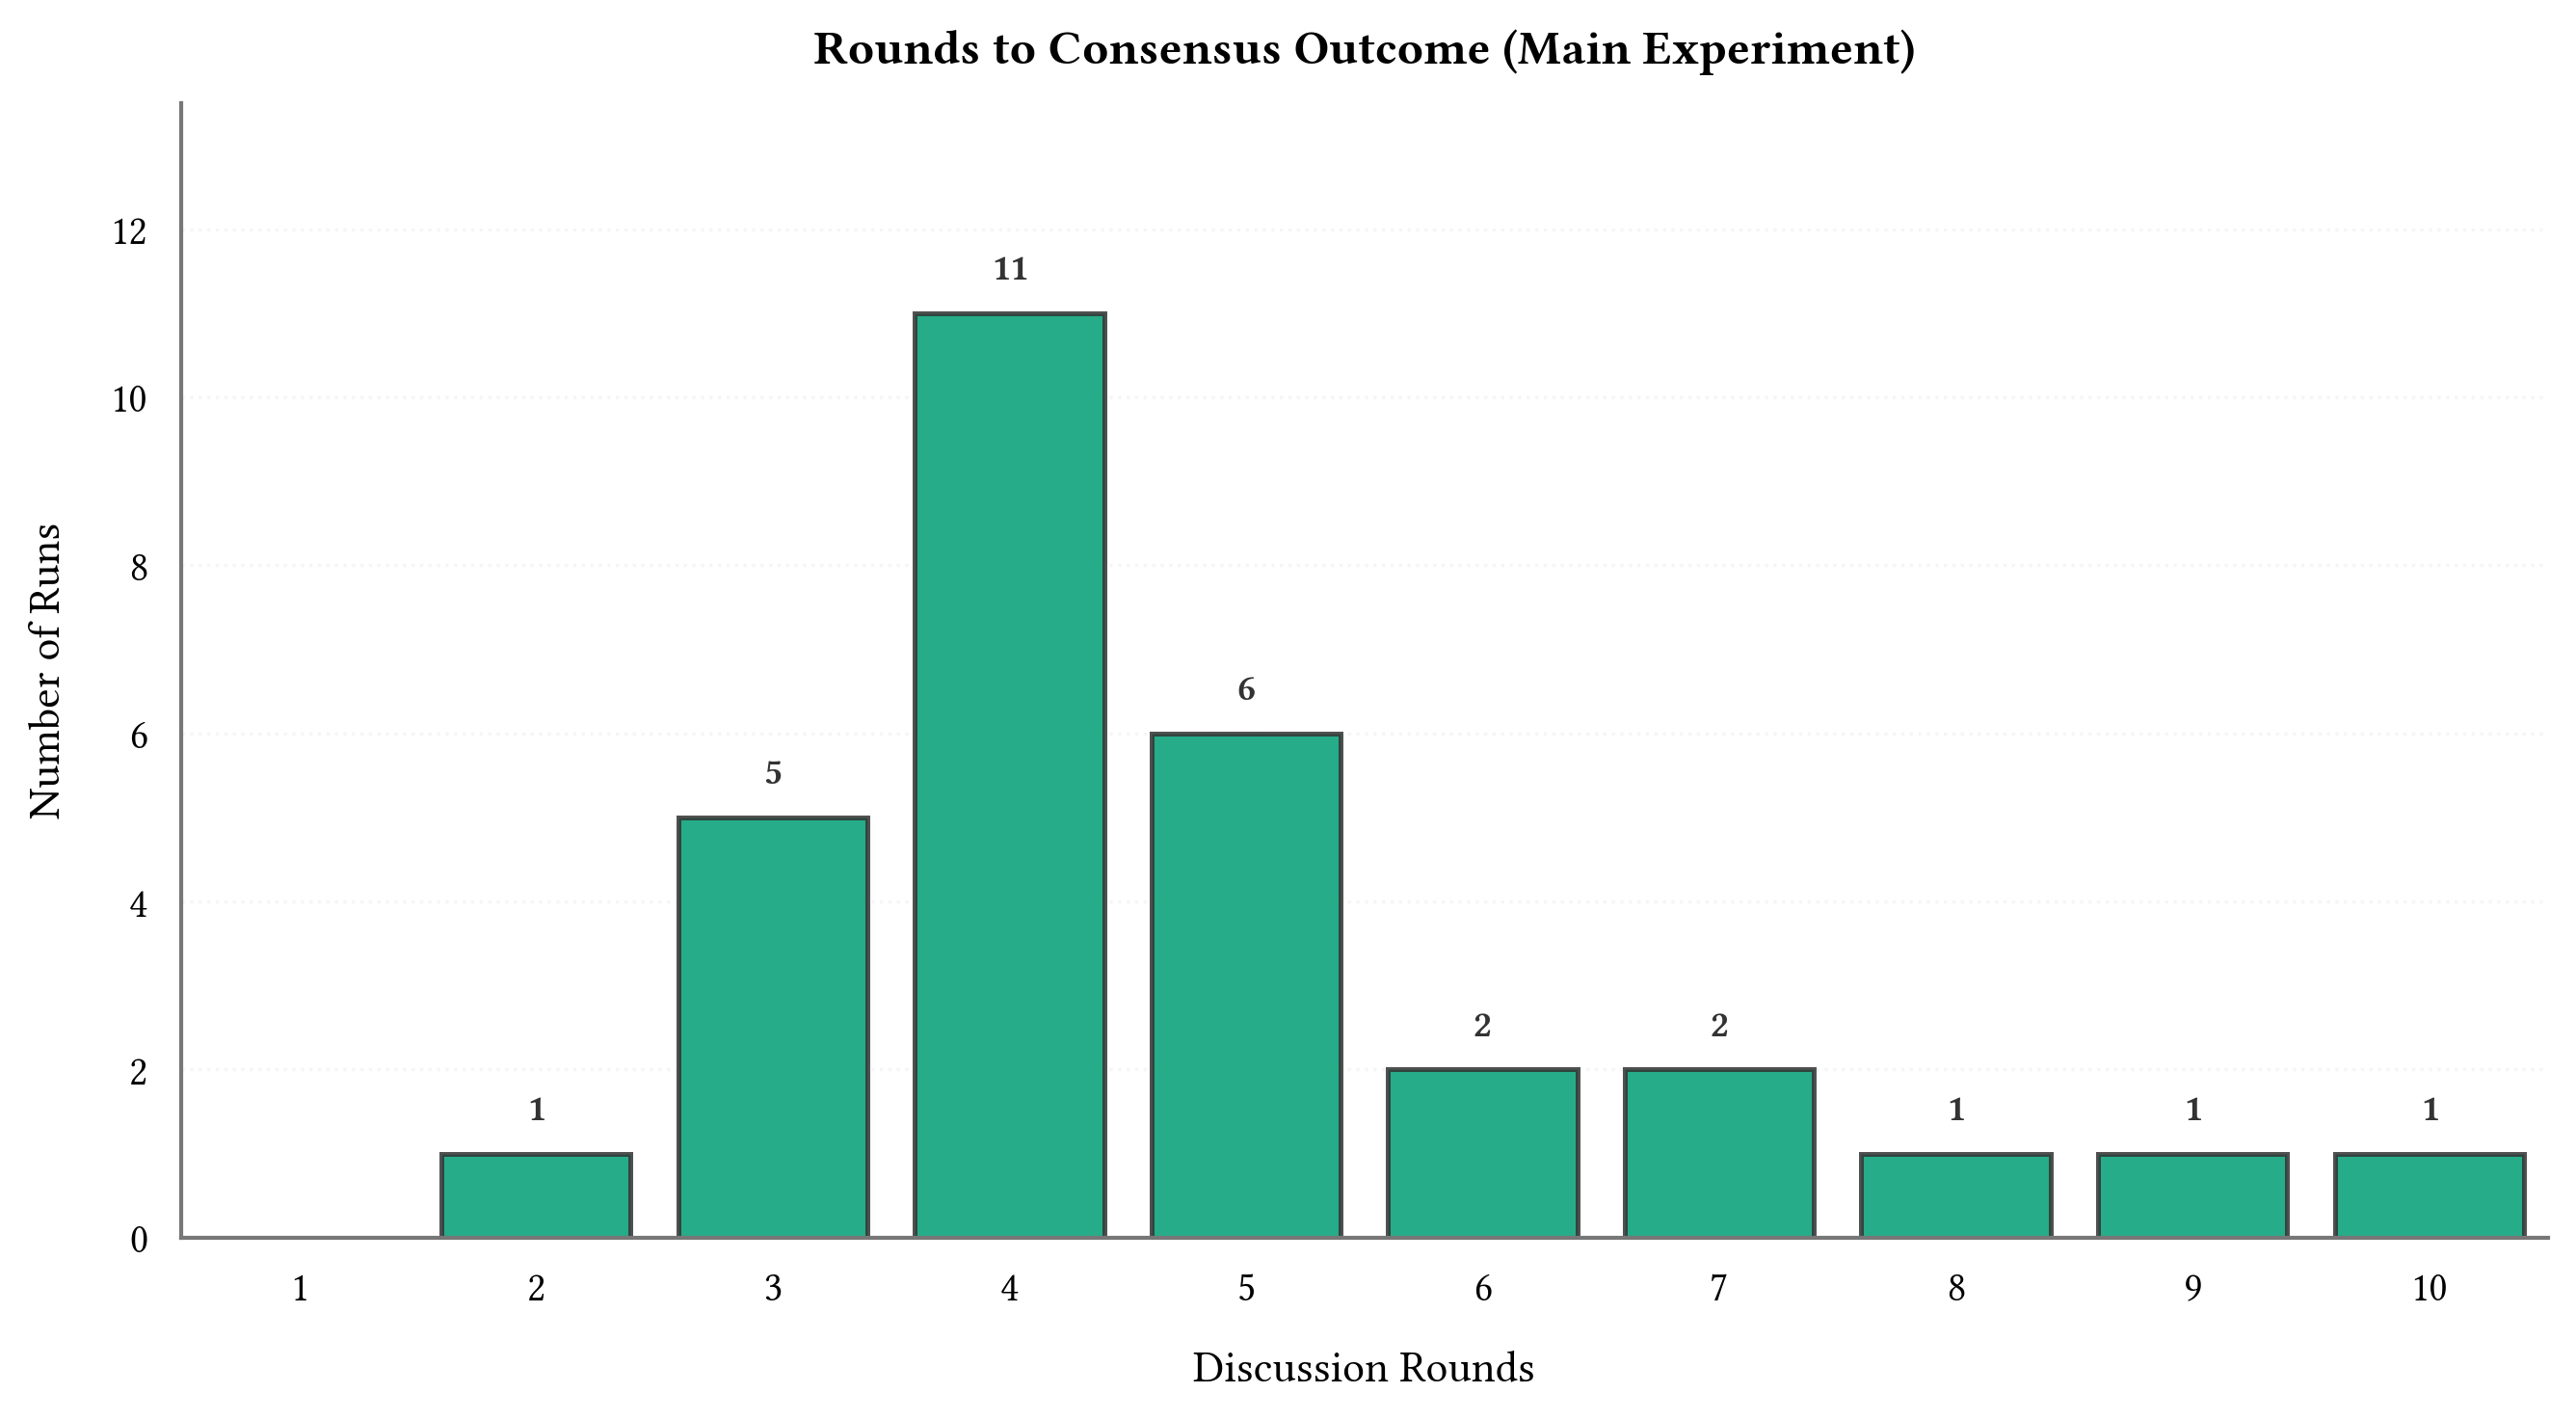

Consensus Timing Summary:
  Total consensus runs: 30
  Range: 2-10 rounds
  Mean: 4.80 rounds  |  Median: 4 rounds


In [ ]:
# Use centralized visualization function
plot_rounds_to_outcome(
    run_metrics,
    title_suffix="Main Experiment"
)

## Preference Evolution and Transitions

The following visualizations track how agents' top-choice preferences change across the four measurement waves, revealing patterns of stability, switching, and long-term loyalty.

In [ ]:
# Build transition data using centralized function
transition_data = build_transition_data(ranking_top)
print(f"Built transition data for {len(transition_data)} agents")
print(f"\nSample transitions:")
display(transition_data.head(10))


Built transition data for 165 agents

Sample transitions:


,run_id,agent,wave1,wave2,wave3,wave4
0,main_experiment_condition_10_config_results,Agent_1,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Floor
1,main_experiment_condition_10_config_results,Agent_2,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor
2,main_experiment_condition_10_config_results,Agent_3,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor
3,main_experiment_condition_10_config_results,Agent_4,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor
4,main_experiment_condition_10_config_results,Agent_5,Max Avg + Floor,Max Avg + Floor,Max Floor,Max Floor
5,main_experiment_condition_11_config_results,Agent_1,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor
6,main_experiment_condition_11_config_results,Agent_2,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor
7,main_experiment_condition_11_config_results,Agent_3,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor
8,main_experiment_condition_11_config_results,Agent_4,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor
9,main_experiment_condition_11_config_results,Agent_5,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor


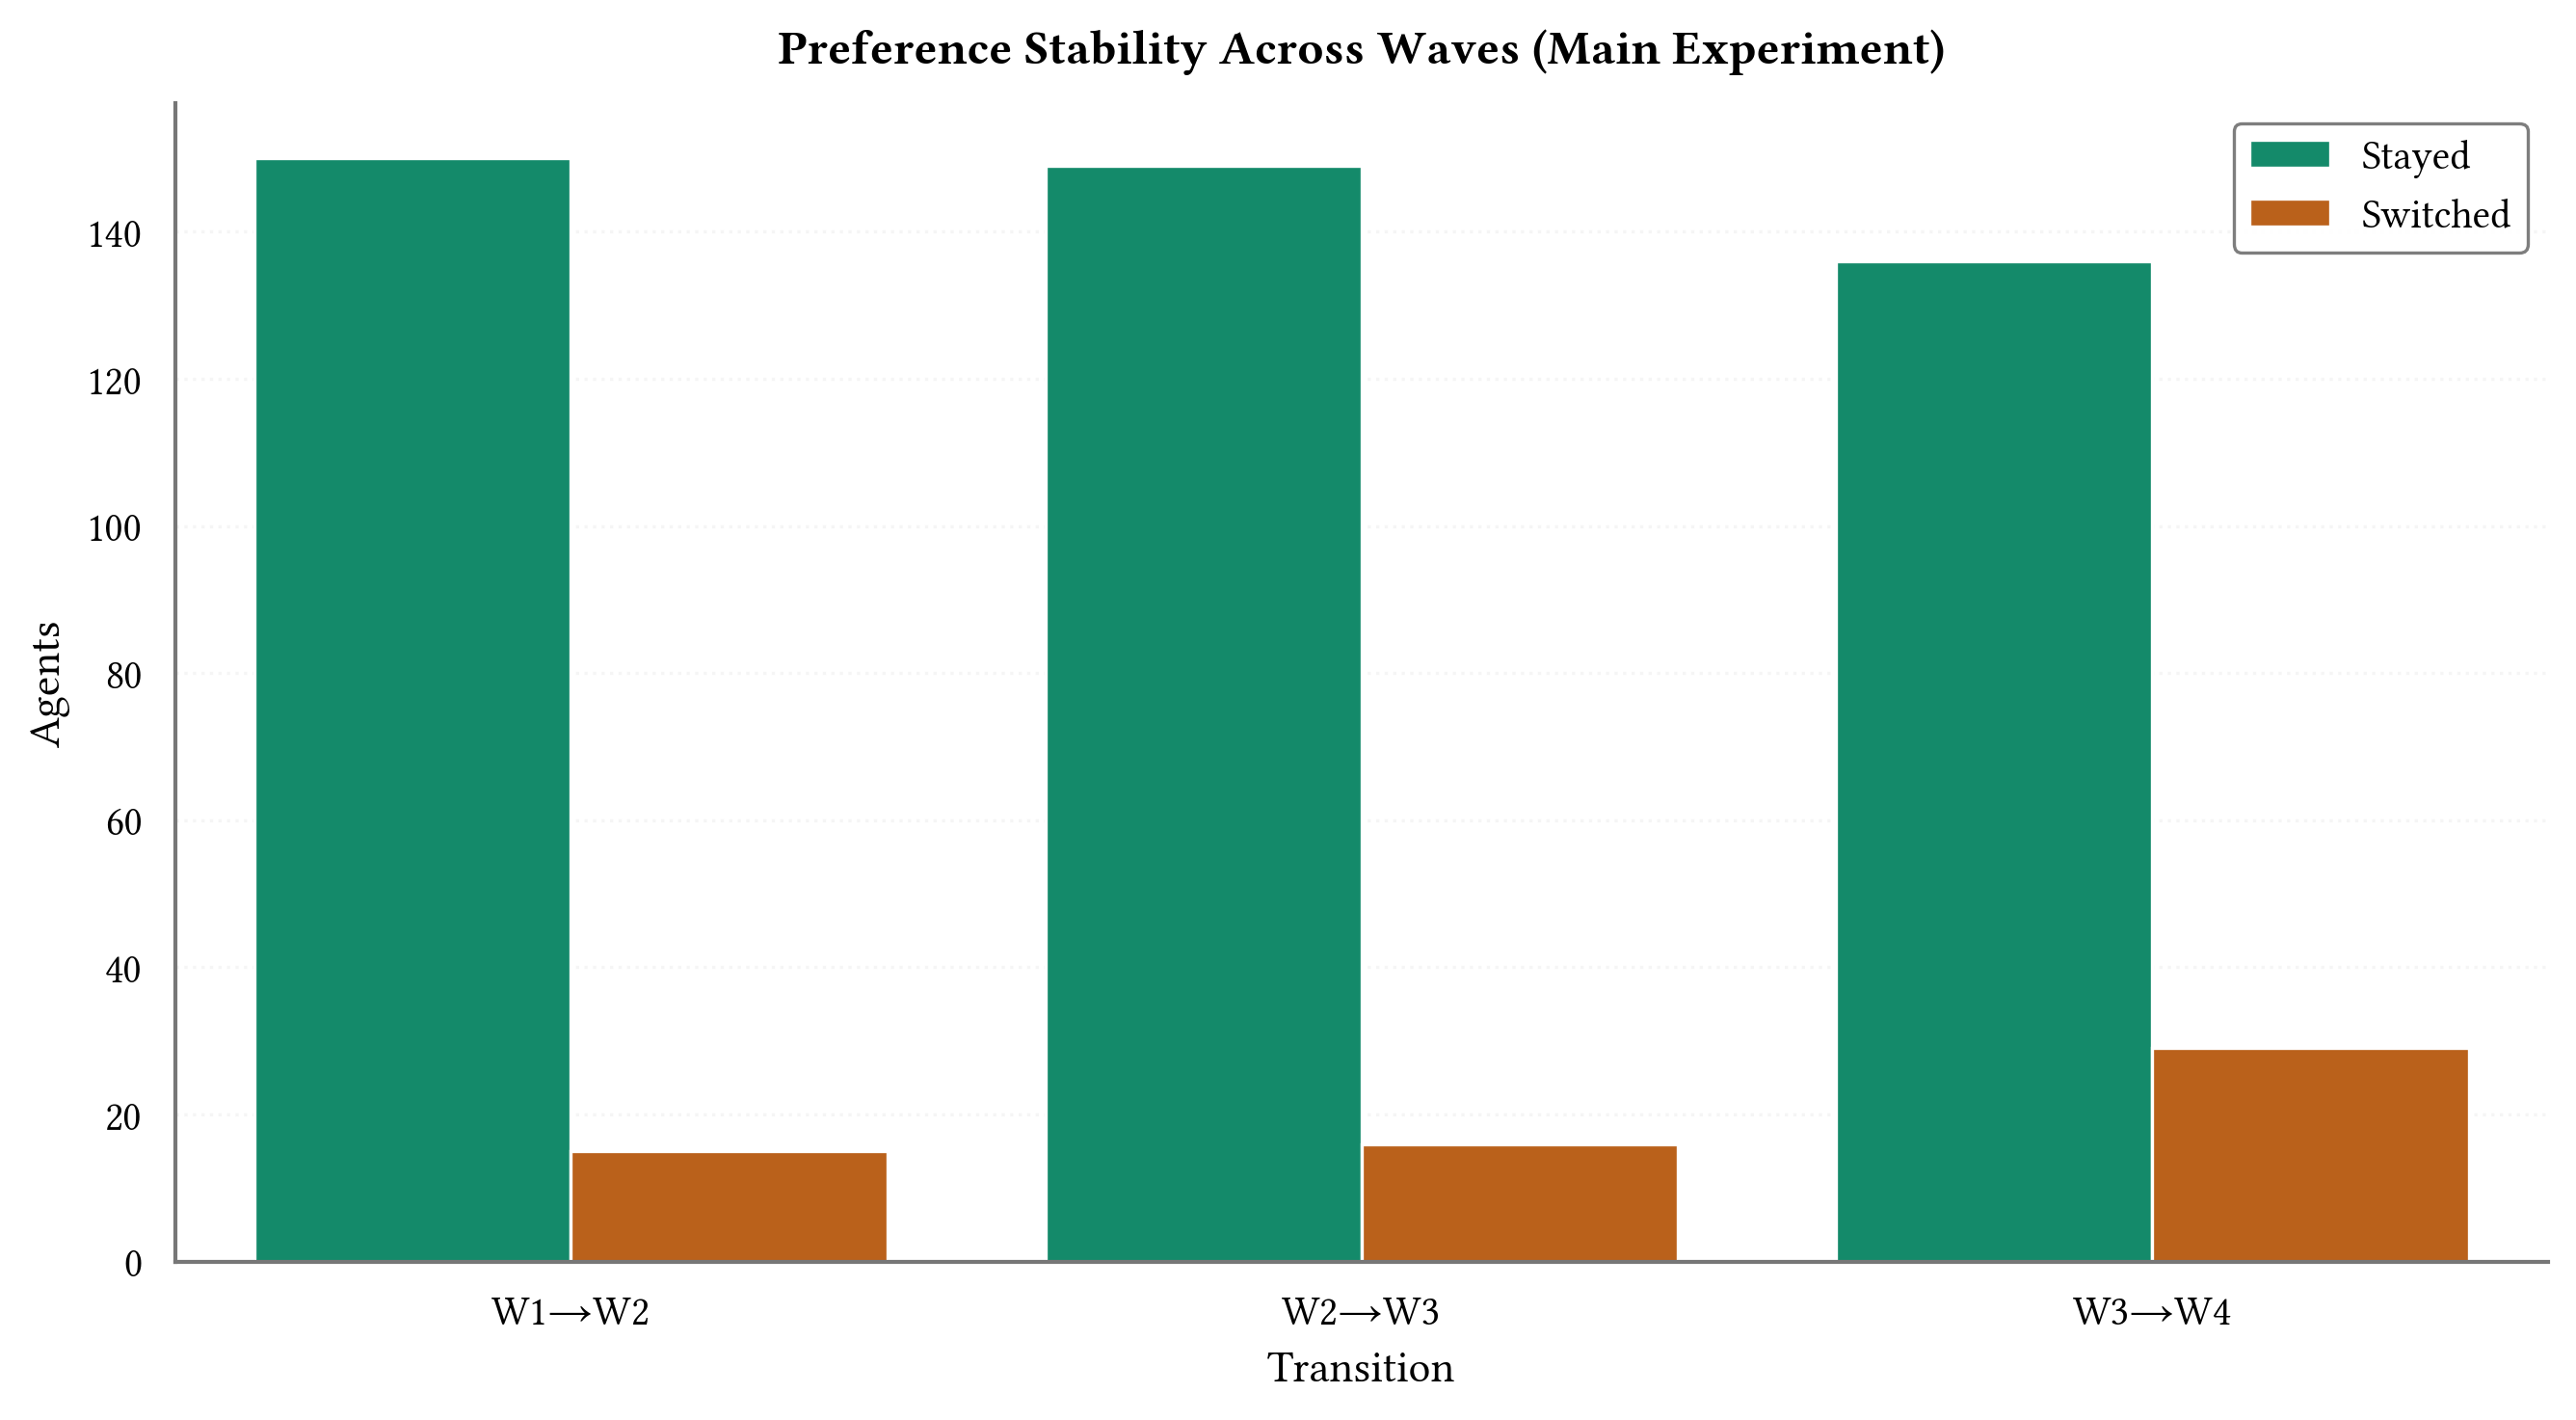

Stability Breakdown:
  W1→W2: 150/165 stayed (90.9%)
  W2→W3: 149/165 stayed (90.3%)
  W3→W4: 136/165 stayed (82.4%)


In [ ]:
# Use centralized visualization function
plot_preference_stability(
    transition_data,
    title_suffix="Main Experiment"
)

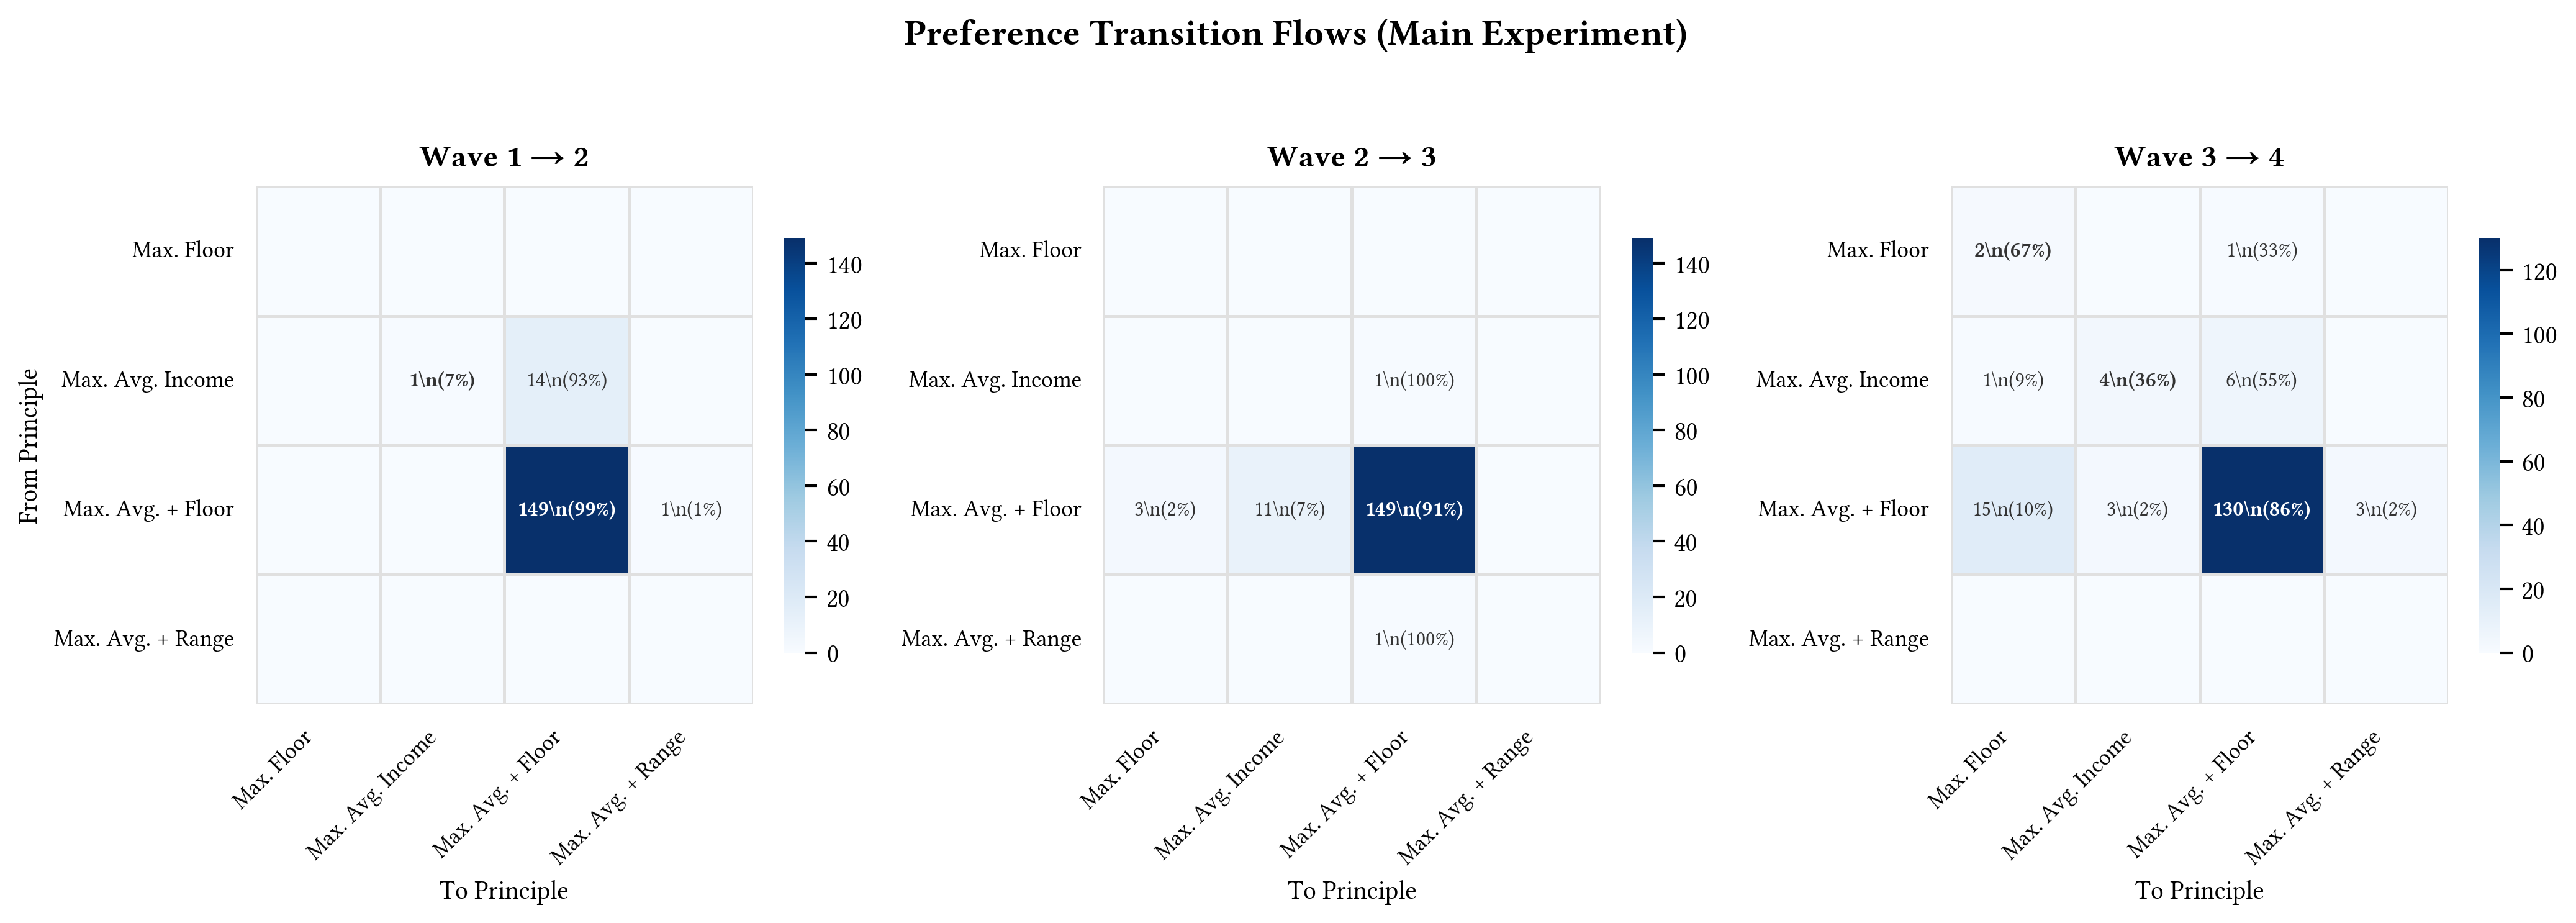

Transition Stay Rates:
  Wave 1 → 2: 150/165 stayed (90.9%)
  Wave 2 → 3: 149/165 stayed (90.3%)
  Wave 3 → 4: 136/165 stayed (82.4%)


In [ ]:
# Use centralized visualization function
principle_display_order = format_principle_labels(PRINCIPLE_ORDER)

plot_transition_heatmaps(
    transition_data,
    principle_display_order=principle_display_order,
    format_principle_label=format_principle_label,
    title_suffix="Main Experiment"
)

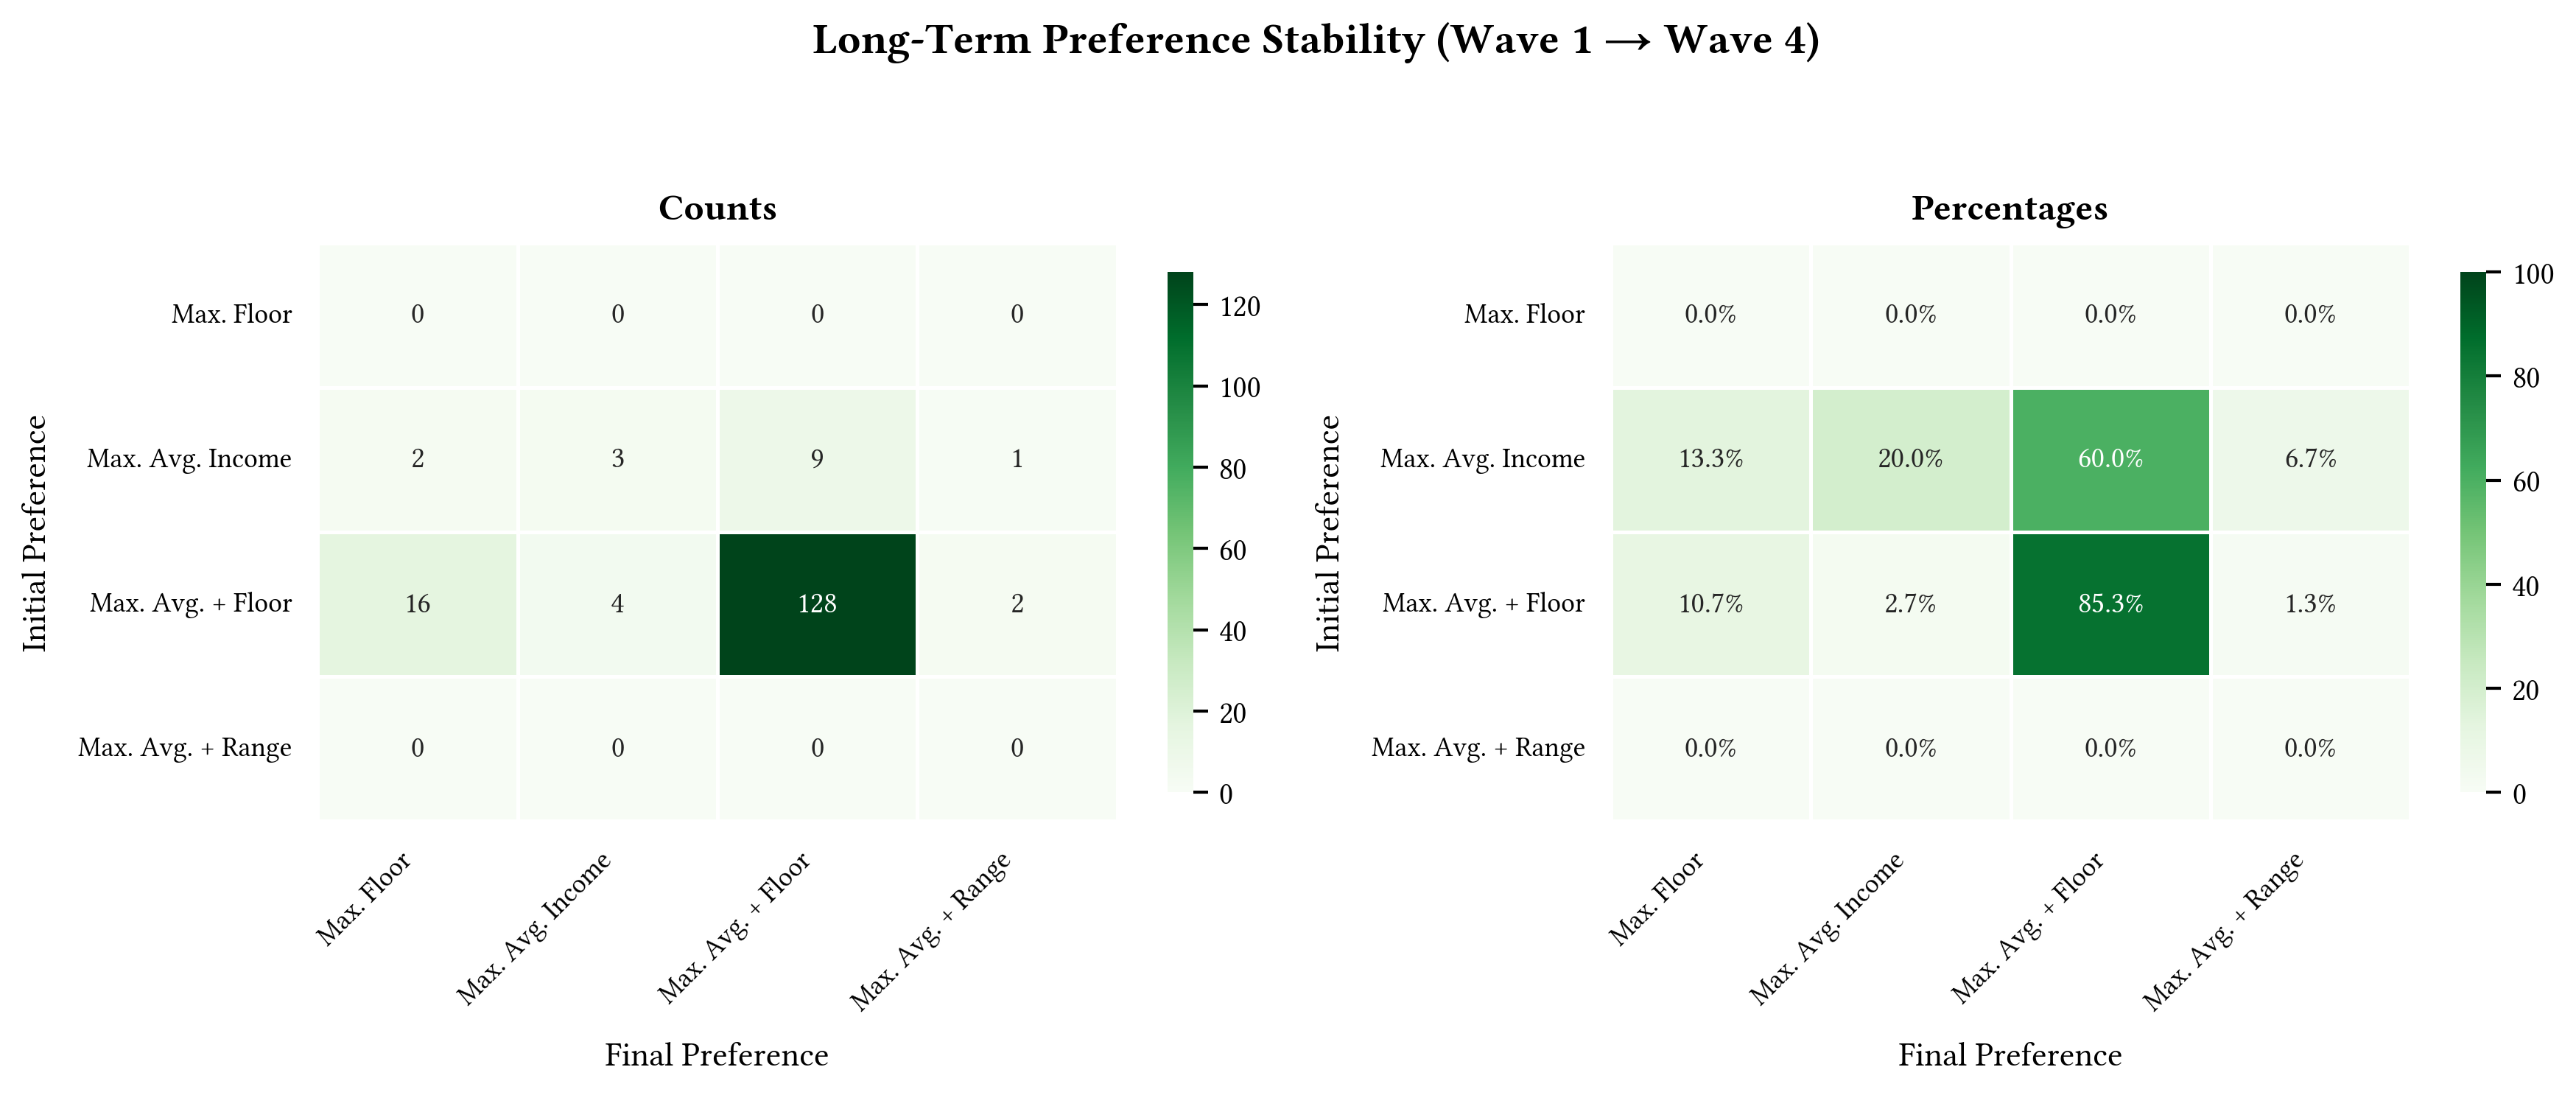

Long-Term Stability (Wave 1 → Wave 4) [Main Experiment]
Max. Floor               :   0/  0 maintained (  0.0%)
Max. Avg. Income         :   3/ 15 maintained ( 20.0%)
Max. Avg. + Floor        : 128/150 maintained ( 85.3%)
Max. Avg. + Range        :   0/  0 maintained (  0.0%)
OVERALL                  : 131/165 agents ( 79.4%)


In [ ]:
# VISUALIZATION: Long-Term Preference Stability (Wave 1 → Wave 4)

principle_order = [
    "Max Floor",
    "Max Avg Income",
    "Max Avg + Floor",
    "Max Avg + Range"
]

principle_display_order = format_principle_labels(principle_order)

# Create the long-term stability visualization
plot_long_term_stability(
    transition_data,
    principle_order=principle_order,
    principle_display_order=principle_display_order,
    format_principle_label=format_principle_label,
    title_suffix="Main Experiment",
    title="Long-Term Preference Stability (Wave 1 → Wave 4)"
)


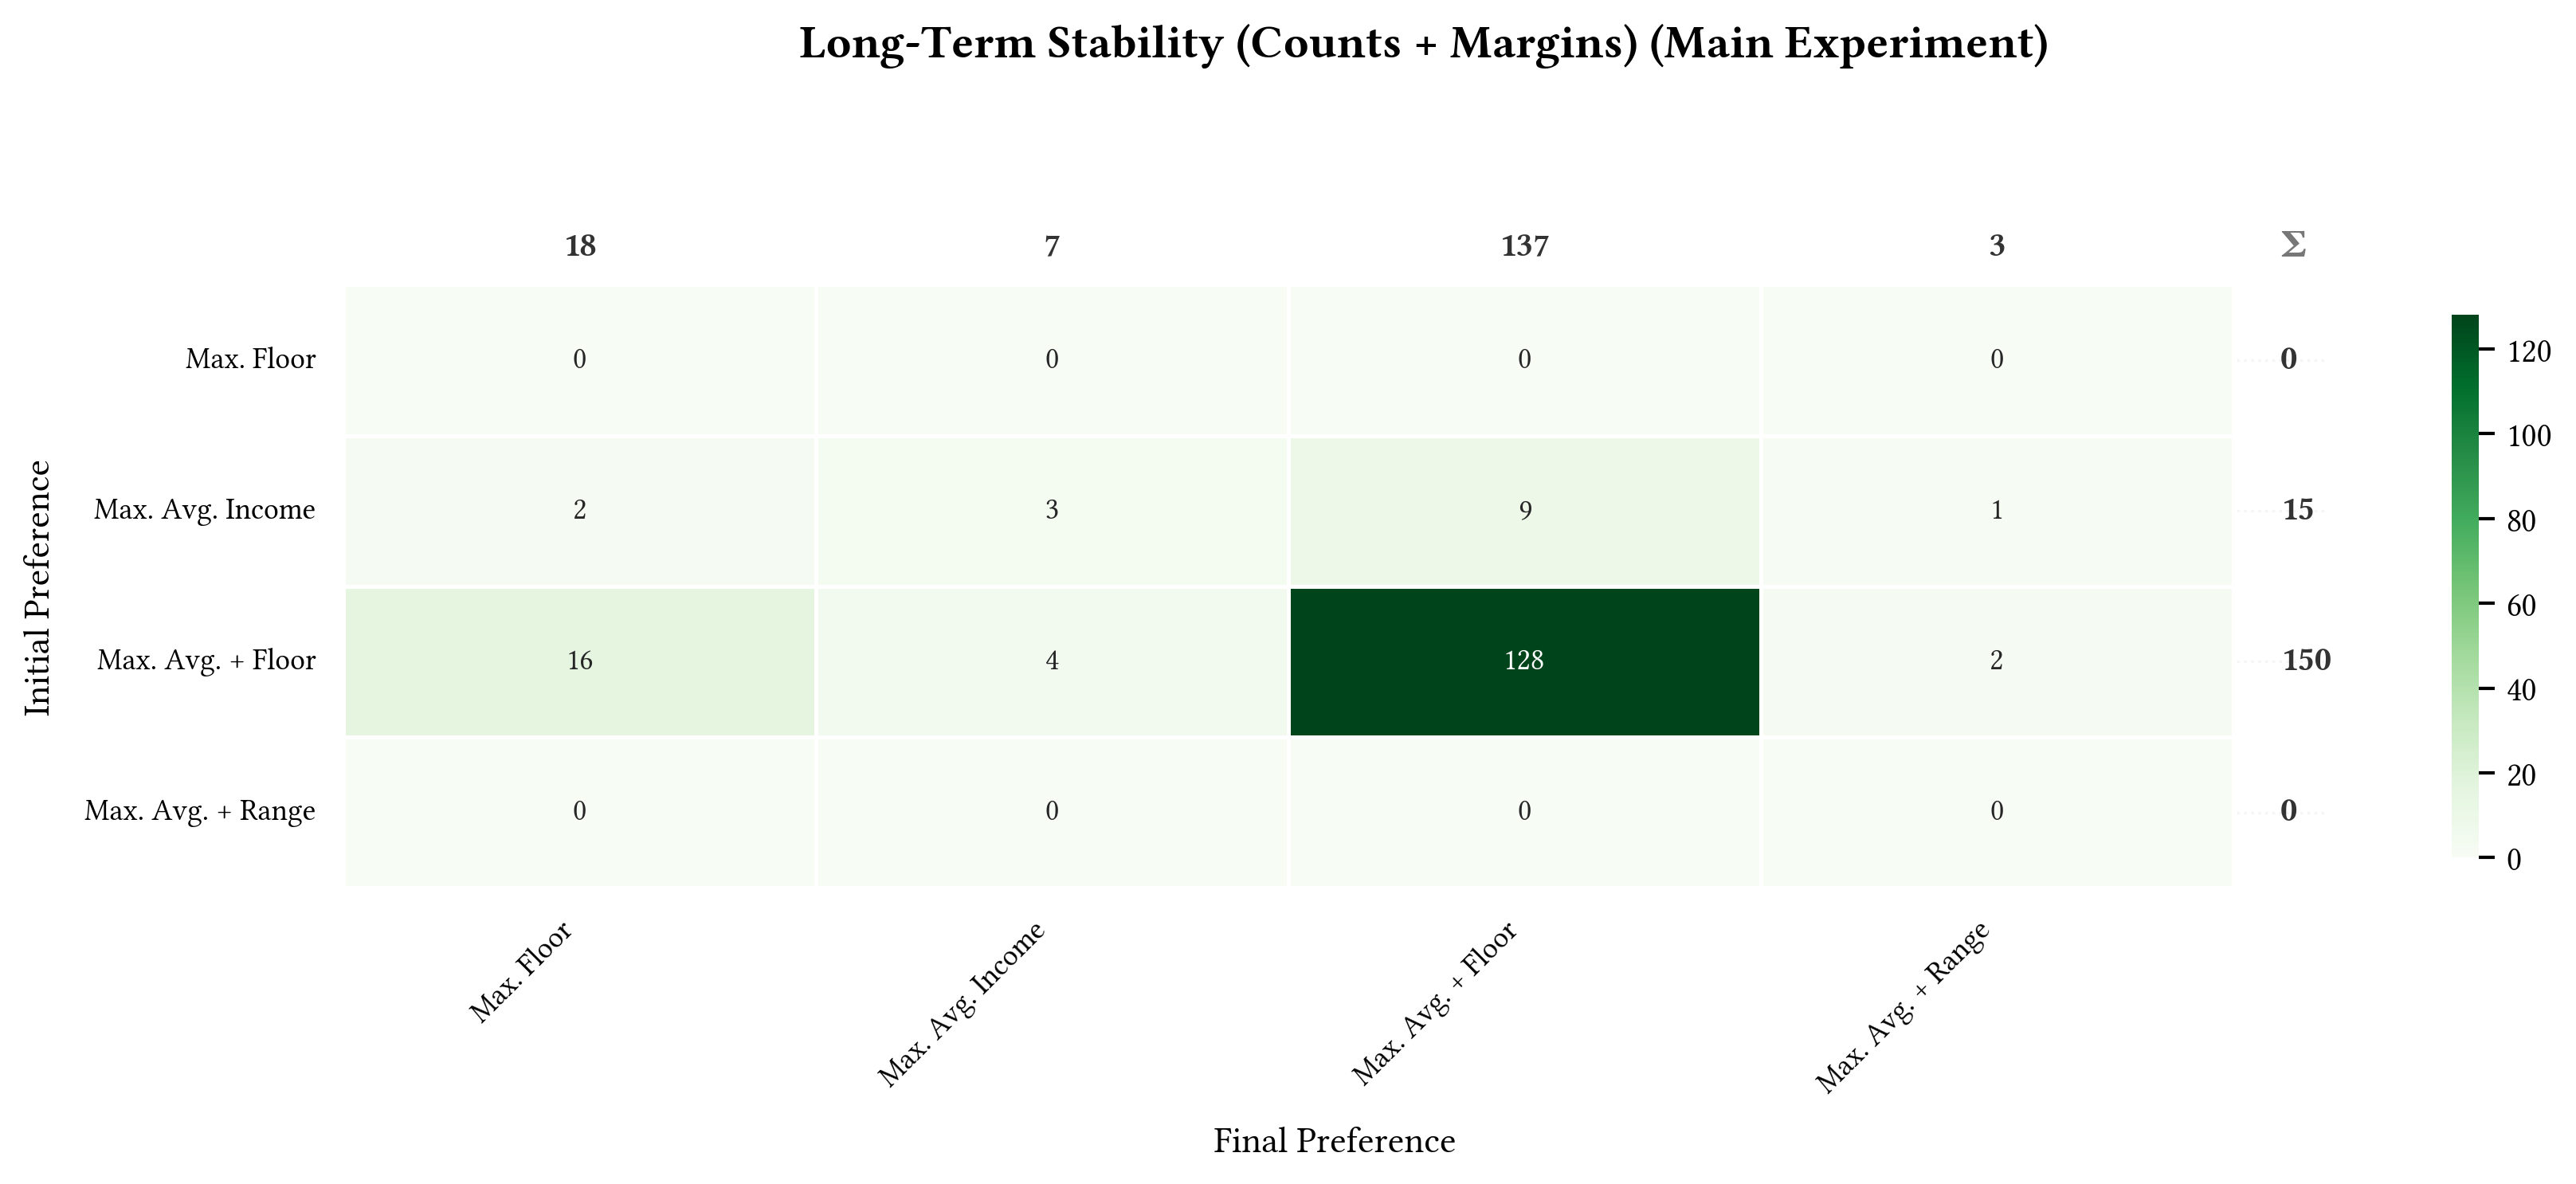

In [ ]:
# VISUALIZATION: Long-Term Preference Stability Counts with Margins
principle_order = [
    "Max Floor",
    "Max Avg Income",
    "Max Avg + Floor",
    "Max Avg + Range"
]

principle_display_order = format_principle_labels(principle_order)

# Create the counts heatmap with margins
plot_long_term_margin(
    transition_data,
    principle_display_order=principle_display_order,
    format_principle_label=format_principle_label,
    title_suffix="Main Experiment",
    title="Long-Term Stability (Counts + Margins) (Main Experiment)",
)


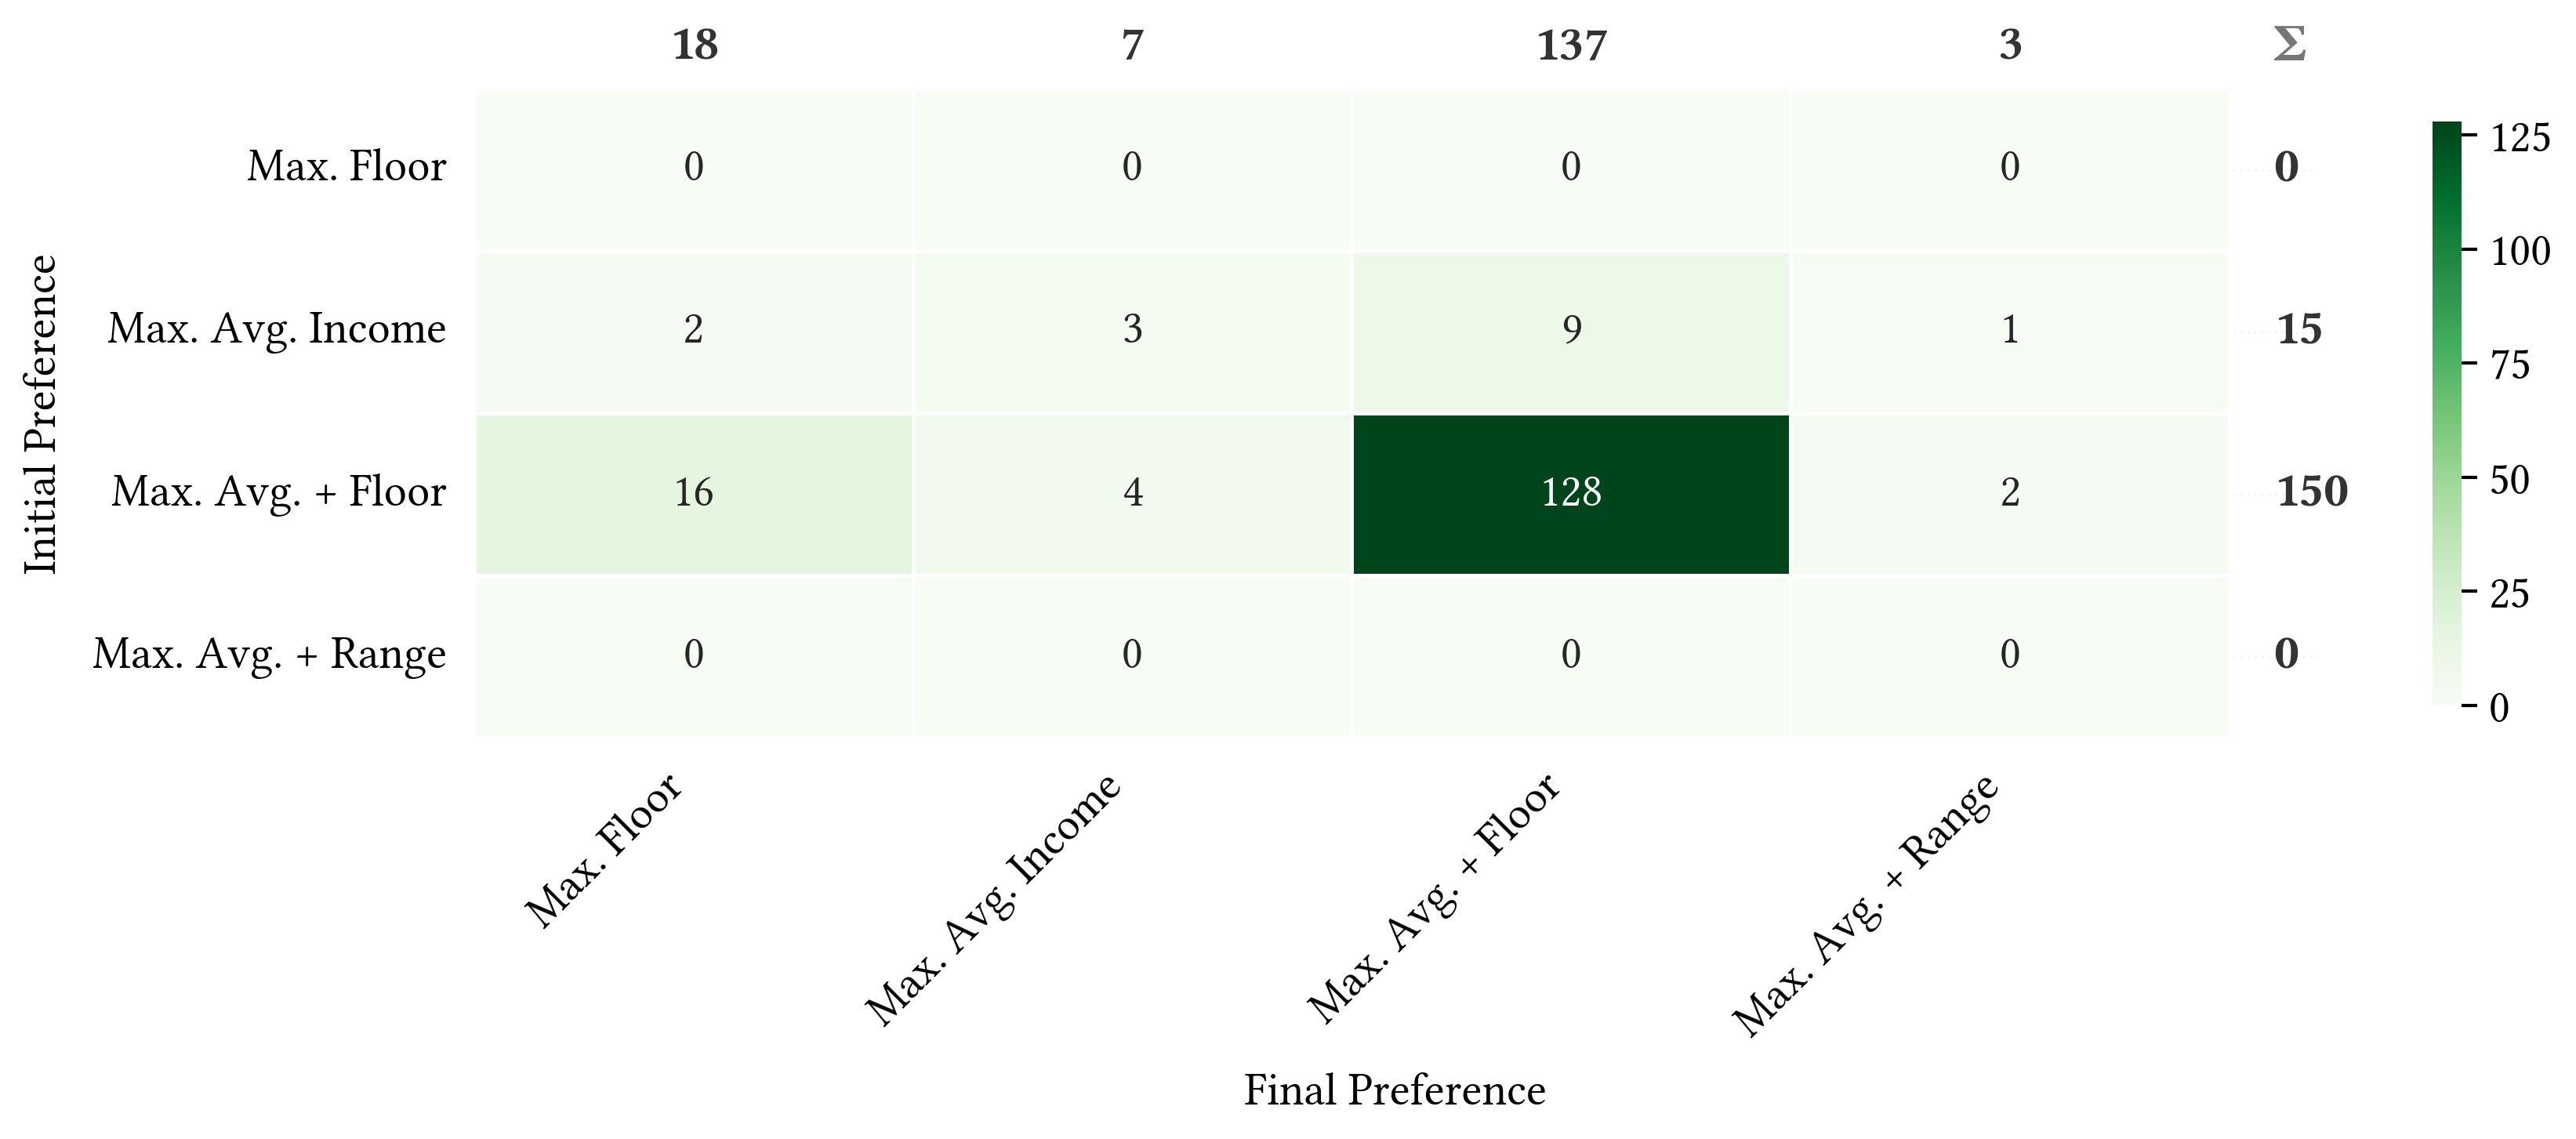

In [ ]:
# Define larger font sizes for better readability
LARGE_FONT_SIZES = {
    "title": 14,
    "subtitle": 14,
    "axis_label": 14,
    "tick_label": 14,
    "legend":14,
    "annotation":14, # Significantly larger numbers inside the heatmap
}

plot_long_term_margin(
    transition_data,
    principle_display_order=principle_display_order,
    format_principle_label=format_principle_label,
    font_sizes=LARGE_FONT_SIZES,
)


## Switcher Analysis: Income Class and Preference Changes

The following analysis investigates whether agents who changed their top-choice preferences have different income class assignments compared to those who remained loyal to their initial preference.

In [ ]:
# Extract income class assignments using centralized function
income_df = extract_income_classes(runs)

print(f"Extracted income data for {len(income_df)} agents")
print(f"\nIncome class distribution:")
income_counts = income_df["income_class"].value_counts().sort_index()
print(income_counts)
print(f"\nPercentages:")
print((income_counts / income_counts.sum() * 100).round(1))

# Show sample
display(income_df.head(15))


Extracted income data for 165 agents

Income class distribution:
income_class
High            7
Low            15
Medium         88
Medium-High    16
Medium-Low     39
Name: count, dtype: int64

Percentages:
income_class
High            4.2
Low             9.1
Medium         53.3
Medium-High     9.7
Medium-Low     23.6
Name: count, dtype: float64


,run_id,agent,income_class_raw,income_class
0,main_experiment_condition_10_config_results,Agent_1,low,Low
1,main_experiment_condition_10_config_results,Agent_2,medium,Medium
2,main_experiment_condition_10_config_results,Agent_3,medium,Medium
3,main_experiment_condition_10_config_results,Agent_4,medium_low,Medium-Low
4,main_experiment_condition_10_config_results,Agent_5,medium,Medium
5,main_experiment_condition_11_config_results,Agent_1,medium_low,Medium-Low
6,main_experiment_condition_11_config_results,Agent_2,medium_low,Medium-Low
7,main_experiment_condition_11_config_results,Agent_3,medium,Medium
8,main_experiment_condition_11_config_results,Agent_4,medium,Medium
9,main_experiment_condition_11_config_results,Agent_5,medium_low,Medium-Low


In [ ]:
# Use centralized function to prepare switcher analysis
switcher_analysis = prepare_switcher_analysis(transition_data, income_df)

# Summary statistics
print("=" * 80)
print("SWITCHER ANALYSIS SUMMARY")
print("=" * 80)
print(f"\nTotal agents analyzed: {len(switcher_analysis)}")
print(f"Agents who switched at ANY point: {switcher_analysis['switched_any'].sum()} ({switcher_analysis['switched_any'].sum()/len(switcher_analysis)*100:.1f}%)")
print(f"Agents who stayed loyal (W1→W4): {(~switcher_analysis['switched_w1_w4']).sum()} ({(~switcher_analysis['switched_w1_w4']).sum()/len(switcher_analysis)*100:.1f}%)")

print("\n\nSwitcher Category Distribution:")
print(switcher_analysis["switcher_category"].value_counts().sort_index())

print("\n\nSwitches by Transition:")
print(f"  W1→W2: {switcher_analysis['switched_w1_w2'].sum()} agents switched")
print(f"  W2→W3: {switcher_analysis['switched_w2_w3'].sum()} agents switched")
print(f"  W3→W4: {switcher_analysis['switched_w3_w4'].sum()} agents switched")

display(switcher_analysis.head(15))

SWITCHER ANALYSIS SUMMARY

Total agents analyzed: 165
Agents who switched at ANY point: 45 (27.3%)
Agents who stayed loyal (W1→W4): 131 (79.4%)


Switcher Category Distribution:
switcher_category
Loyal (No switches)               120
Minor switcher (1 switch)          30
Moderate switcher (2 switches)     15
Name: count, dtype: int64


Switches by Transition:
  W1→W2: 15 agents switched
  W2→W3: 16 agents switched
  W3→W4: 29 agents switched


,run_id,agent,wave1,wave2,wave3,wave4,income_class_raw,income_class,switched_w1_w2,switched_w2_w3,switched_w3_w4,switched_any,switched_w1_w4,num_switches,switcher_category
0,main_experiment_condition_10_config_results,Agent_1,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Floor,low,Low,False,False,True,True,True,1,Minor switcher (1 switch)
1,main_experiment_condition_10_config_results,Agent_2,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,medium,Medium,False,False,False,False,False,0,Loyal (No switches)
2,main_experiment_condition_10_config_results,Agent_3,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,medium,Medium,False,False,False,False,False,0,Loyal (No switches)
3,main_experiment_condition_10_config_results,Agent_4,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,medium_low,Medium-Low,False,False,False,False,False,0,Loyal (No switches)
4,main_experiment_condition_10_config_results,Agent_5,Max Avg + Floor,Max Avg + Floor,Max Floor,Max Floor,medium,Medium,False,True,False,True,True,1,Minor switcher (1 switch)
5,main_experiment_condition_11_config_results,Agent_1,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,medium_low,Medium-Low,False,False,False,False,False,0,Loyal (No switches)
6,main_experiment_condition_11_config_results,Agent_2,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,medium_low,Medium-Low,False,False,False,False,False,0,Loyal (No switches)
7,main_experiment_condition_11_config_results,Agent_3,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,medium,Medium,False,False,False,False,False,0,Loyal (No switches)
8,main_experiment_condition_11_config_results,Agent_4,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,medium,Medium,False,False,False,False,False,0,Loyal (No switches)
9,main_experiment_condition_11_config_results,Agent_5,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,Max Avg + Floor,medium_low,Medium-Low,False,False,False,False,False,0,Loyal (No switches)


In [ ]:
# Use centralized function to create income comparison summary
switcher_summary, count_long, share_long, composition_percent_long = summarize_income_preferences(switcher_analysis)

# Display the summary table
print("=" * 90)
print("INCOME CLASS DISTRIBUTION BY PREFERENCE STABILITY")
print("=" * 90)
switchers = switcher_analysis[switcher_analysis["switched_any"] == True]
maintainers = switcher_analysis[switcher_analysis["switched_any"] == False]
print(f"Changed preference: {len(switchers)} agents | Maintained preference: {len(maintainers)} agents")
print("=" * 90)
display(switcher_summary)

INCOME CLASS DISTRIBUTION BY PREFERENCE STABILITY
Changed preference: 45 agents | Maintained preference: 120 agents


,Income Class,Changed Preference Count,Changed Preference %,Maintained Preference Count,Maintained Preference %,Diff Changed vs Maintained (pp)
0,Low,12,26.7,3,2.5,24.2
1,Medium-Low,13,28.9,26,21.7,7.2
2,Medium,18,40.0,70,58.3,-18.3
3,Medium-High,2,4.4,14,11.7,-7.3
4,High,0,0.0,7,5.8,-5.8


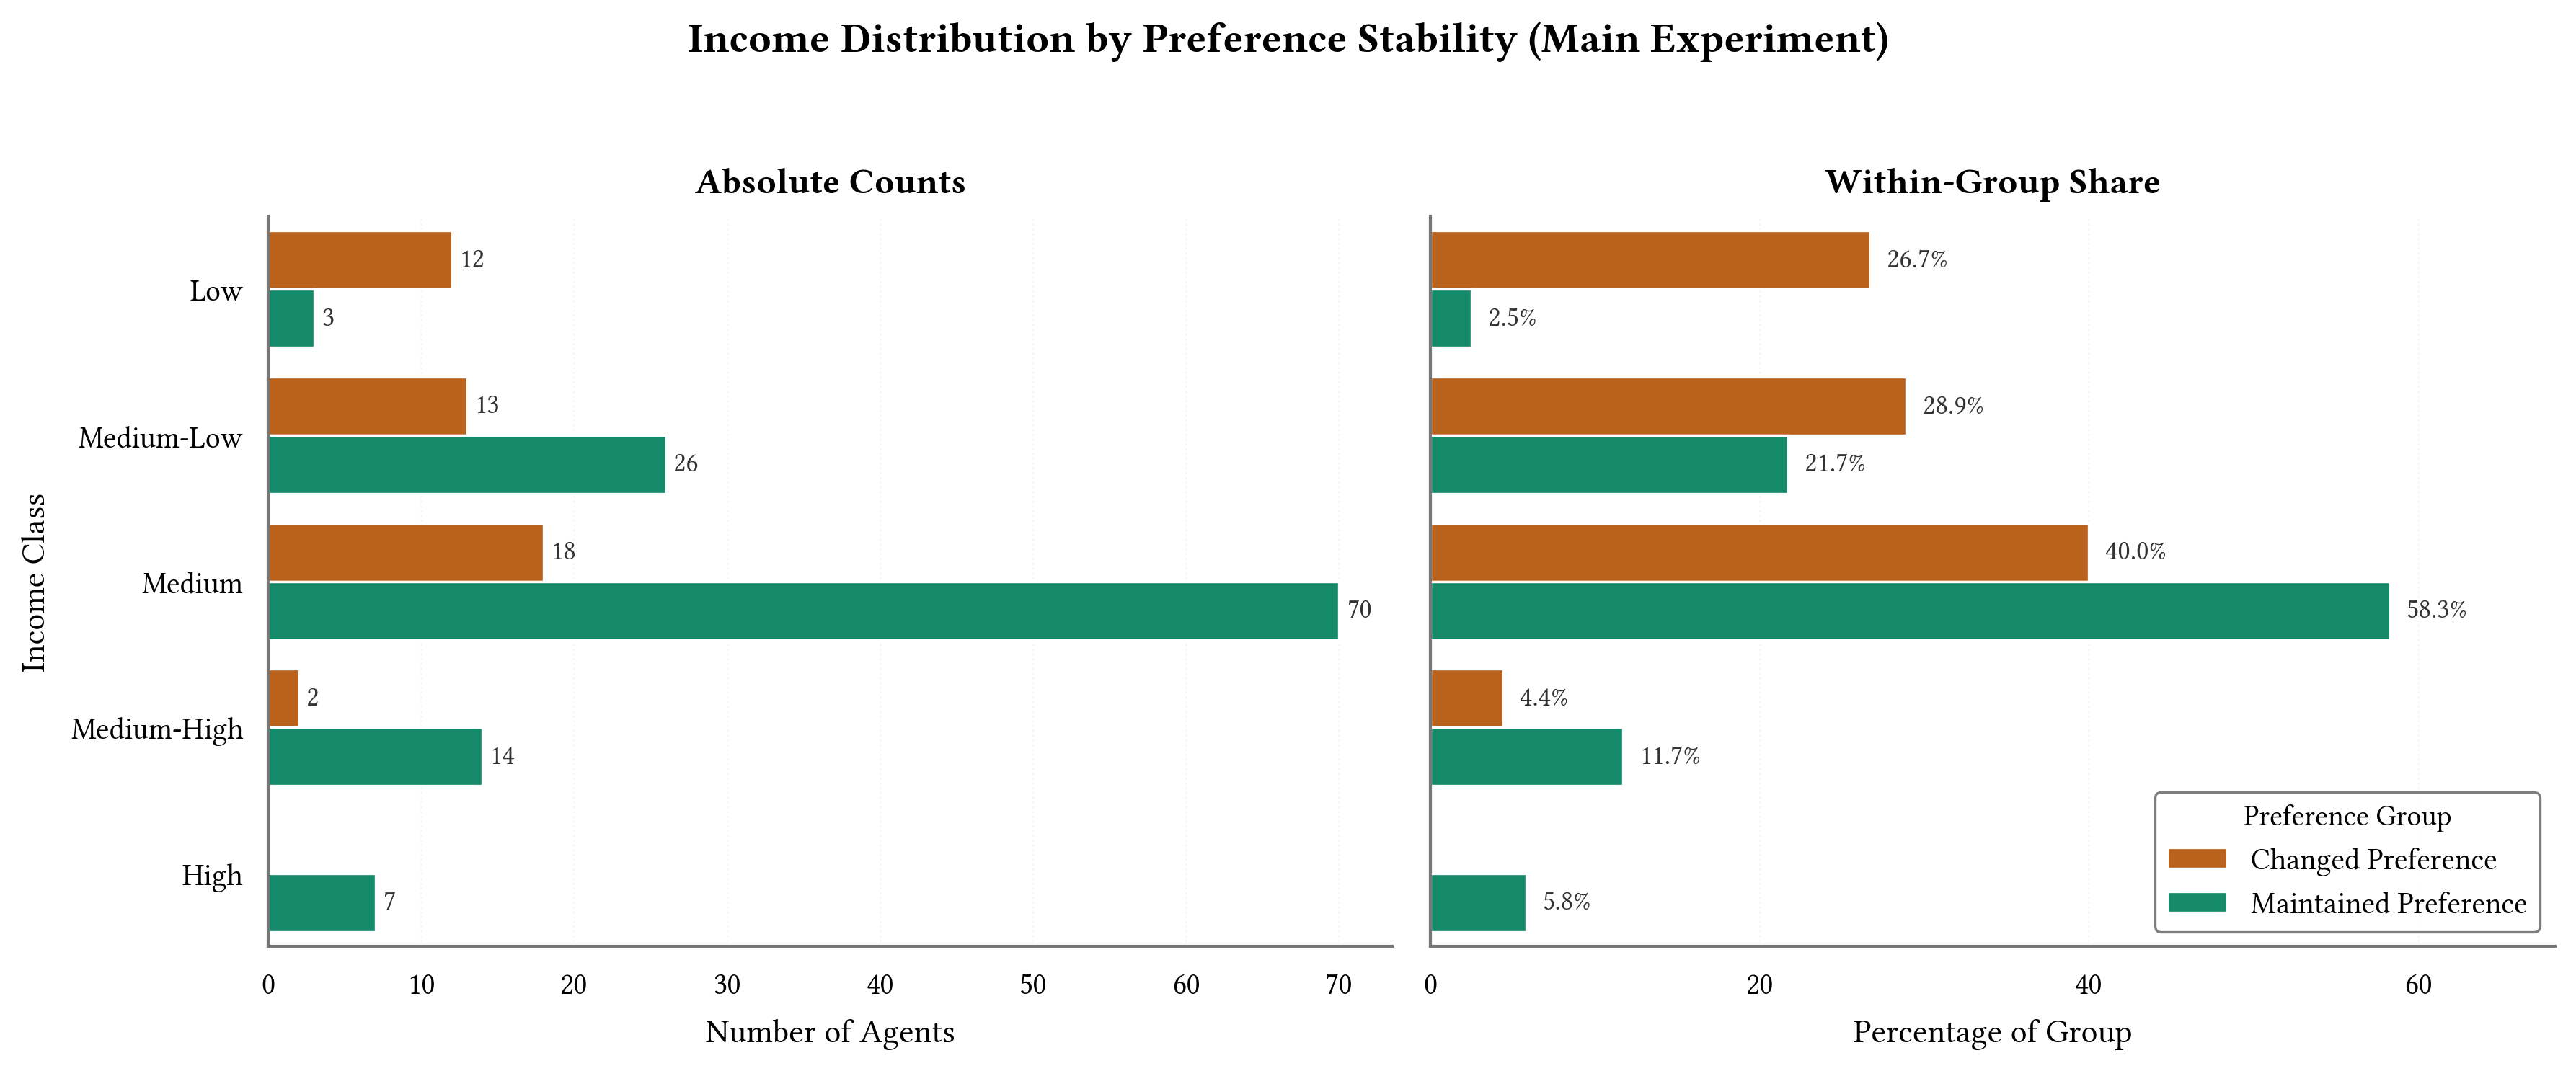

In [ ]:
# Use centralized visualization function
plot_income_preference_bars(
    switcher_summary,
    count_long,
    share_long,
    title_suffix="Main Experiment"
)

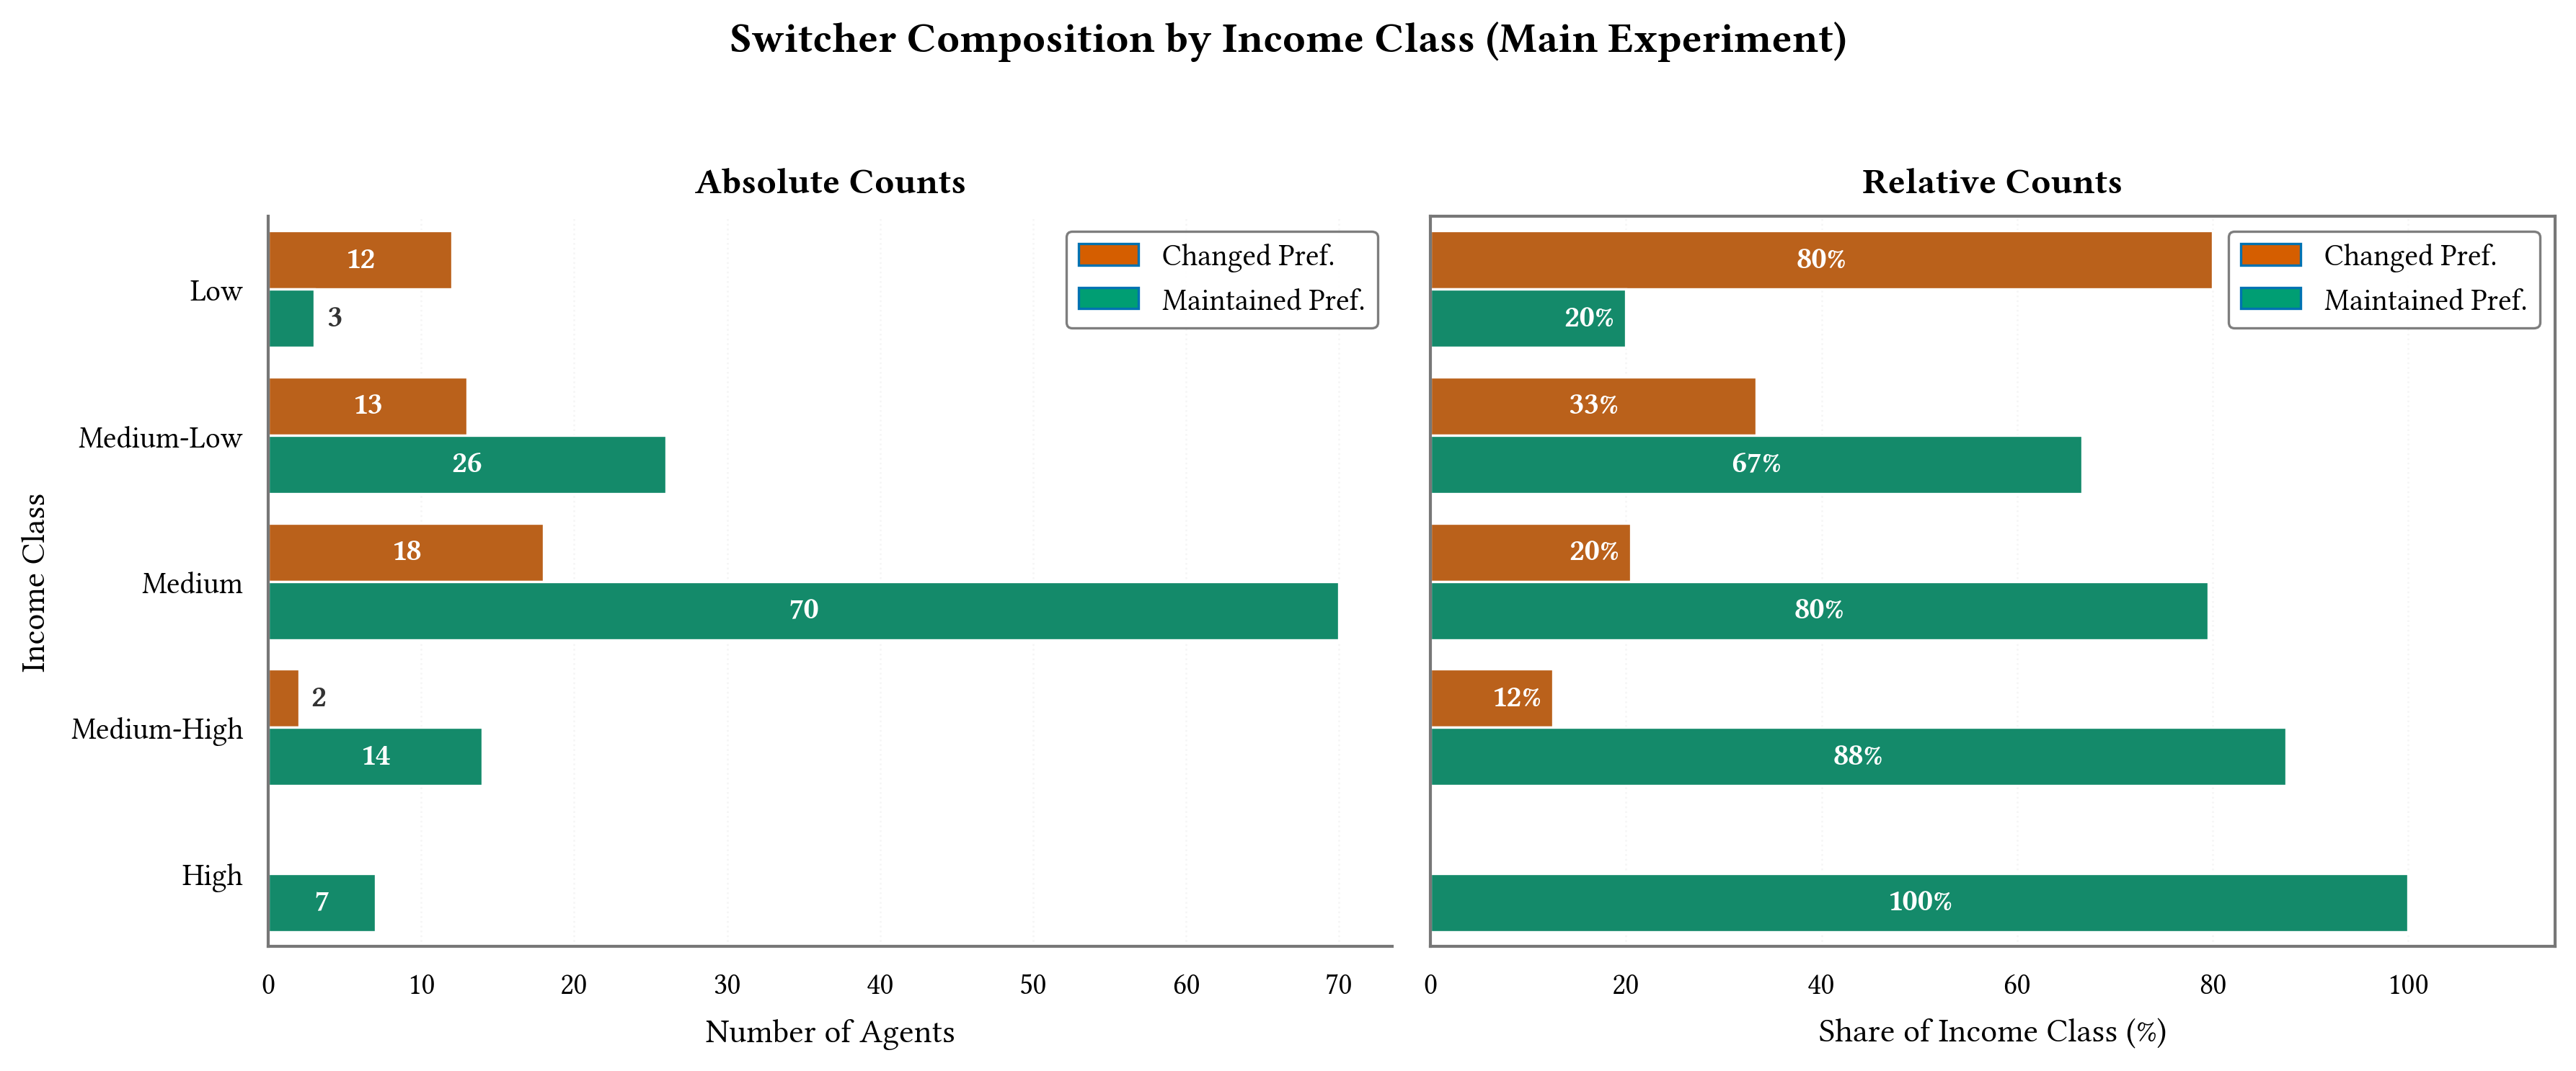

In [ ]:
# Use centralized visualization function
plot_income_composition(
    count_long,
    composition_percent_long,
    title_suffix="Main Experiment"
)